# Analysis of Model Performance on BayesEval

We have three research questions in mind for this analysis:

**RQ 1:** What is the nature of LLM calibration
<br>
**RQ 2:** What role does task difficulty play in model calibration? 
<br>
**RQ 3:** Does prompting models to output SPDs improve calibration?
<br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


ROOT_DIR = Path("..").resolve()
RESULTS_PATH = ROOT_DIR / Path("results")
FIGURES_PATH = "figs/"
MODELS = ["anthropic_claude-haiku-4.5", "google_gemini-2.5-flash", "meta-llama_llama-4-maverick", "openai_gpt-5.4-mini"]
MODEL_LABELS = ["Claude Haiku 4.5", "Gemini 2.5 Flash", "Llama 4 Maverick", "GPT-5.4 Mini"]

# Okabe-Ito colorblind-safe palette
CB_PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
MODEL_COLORS = dict(zip(MODELS, CB_PALETTE))

mpl.rcParams.update({
    "font.family":           "sans-serif",
    "font.sans-serif":       ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":             8,
    "axes.labelsize":        7,
    "axes.titlesize":        7,
    "xtick.labelsize":       6,
    "ytick.labelsize":       6,
    "legend.fontsize":       6,
    "legend.title_fontsize": 8,
    "lines.linewidth":       1.2,
    "lines.markersize":      4,
    "patch.linewidth":       0.5,
    "axes.linewidth":        0.6,
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.prop_cycle":       plt.cycler(color=CB_PALETTE),
    "xtick.major.width":     0.6,
    "ytick.major.width":     0.6,
    "xtick.direction":       "in",
    "ytick.direction":       "in",
    "text.color":            "#333333",
    "axes.edgecolor":        "#333333",
    "axes.labelcolor":       "#333333",
    "xtick.color":           "#333333",
    "ytick.color":           "#333333",
    "axes.grid":             False,
    "legend.frameon":        False,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
    "figure.dpi":            150,
})

# 11 bins: [0.0,0.1), [0.1,0.2), ..., [0.9,1.0), [1.0]
BIN_EDGES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.01]
BIN_LABELS = ["[0.0,0.1)", "[0.1,0.2)", "[0.2,0.3)", "[0.3,0.4)", "[0.4,0.5)",
              "[0.5,0.6)", "[0.6,0.7)", "[0.7,0.8)", "[0.8,0.9)", "[0.9,1.0)", "[1.0]"]
BIN_MIDPOINTS = np.array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0])

SIZE_MIN, SIZE_MAX = 10, 50

def calibration_plot(ax, df, correct_col, title):
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=0.8)
    for model, label in zip(MODELS, MODEL_LABELS):
        model_df = df[df["model"] == model].copy()
        model_df["bin"] = pd.cut(model_df["Confidence"], bins=BIN_EDGES,
                                 right=False, labels=BIN_LABELS, include_lowest=True)
        bin_stats = model_df.groupby("bin", observed=False).agg(
            frac_correct=(correct_col, "mean"),
            count=(correct_col, "count")
        ).reset_index()
        p = bin_stats["frac_correct"].values
        n = bin_stats["count"].values
        mask = n > 0
        n_max = n[mask].max() if mask.any() else 1
        sizes = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * n[mask] / n_max
        color = MODEL_COLORS[model]
        ax.plot(BIN_MIDPOINTS[mask], p[mask], color=color, linewidth=1.2, alpha=0.8)
        ax.scatter(BIN_MIDPOINTS[mask], p[mask], s=sizes, color=color,
                   label=label, edgecolors="white", linewidths=0.5, zorder=3)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Confidence")
    ax.set_title(title)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

# Weight Guessing Dataset (WGD)

In [2]:
wgd_df = pd.DataFrame()
wgd_path = RESULTS_PATH / Path("WGD")
for model in MODELS:
    new_df_path = wgd_path / Path(f"{model}.csv")
    new_df = pd.read_csv(new_df_path)
    new_df["model"] = model
    wgd_df = pd.concat([wgd_df, new_df])
    
wgd_df.reset_index(inplace = True)
wgd_df.tail()

,index,question_id,Answer,Confidence,raw,error,photo,within_lbs,true_weight,model
18475,4615,wgd_301_16,155.0,0.62,"{""Answer"":""155"",""Confidence"":""0.62""}",NaN,301.jpg,16,150.0,openai_gpt-5.4-mini
18476,4616,wgd_301_17,150.0,0.43,"{""Answer"":""150"",""Confidence"":""0.43""}",NaN,301.jpg,17,150.0,openai_gpt-5.4-mini
18477,4617,wgd_301_18,150.0,0.52,"{""Answer"":""150"",""Confidence"":""0.52""}",NaN,301.jpg,18,150.0,openai_gpt-5.4-mini
18478,4618,wgd_301_19,150.0,0.52,"{""Answer"":""150"",""Confidence"":""0.52""}",NaN,301.jpg,19,150.0,openai_gpt-5.4-mini
18479,4619,wgd_301_20,155.0,0.56,"{""Answer"":""155"",""Confidence"":""0.56""}",NaN,301.jpg,20,150.0,openai_gpt-5.4-mini


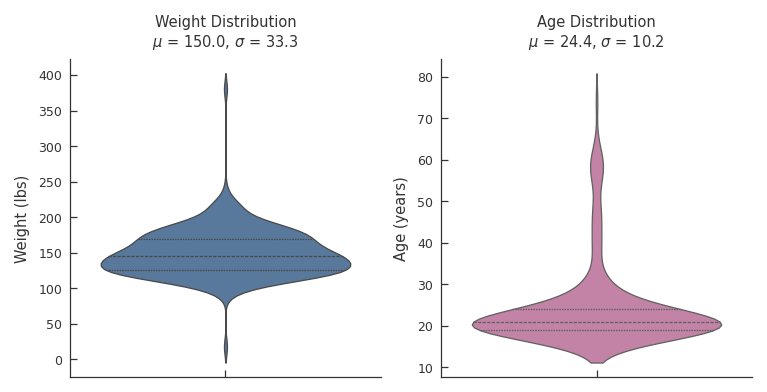

In [3]:
# WGD Dataset Demographics
wgd_labels = pd.read_csv(ROOT_DIR / "domains" / "WGD" / "Data" / "labels.csv")
wgd_labels = wgd_labels.dropna(subset=["Age", "Weight", "sex", "ethnicity"])

fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5), layout="constrained")

# Violin: Weight distribution
sns.violinplot(y=wgd_labels["Weight"], ax=axes[0], color="#4E79A7", inner="quart")
axes[0].set_ylabel("Weight (lbs)")
w_mu, w_sigma = wgd_labels["Weight"].mean(), wgd_labels["Weight"].std()
axes[0].set_title(f"Weight Distribution\n$\\mu$ = {w_mu:.1f}, $\\sigma$ = {w_sigma:.1f}")

# Violin: Age distribution
sns.violinplot(y=wgd_labels["Age"], ax=axes[1], color="#CC79A7", inner="quart")
axes[1].set_ylabel("Age (years)")
a_mu, a_sigma = wgd_labels["Age"].mean(), wgd_labels["Age"].std()
axes[1].set_title(f"Age Distribution\n$\\mu$ = {a_mu:.1f}, $\\sigma$ = {a_sigma:.1f}")

Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/wgd_weight_age.png", dpi=300, bbox_inches="tight")
plt.show()

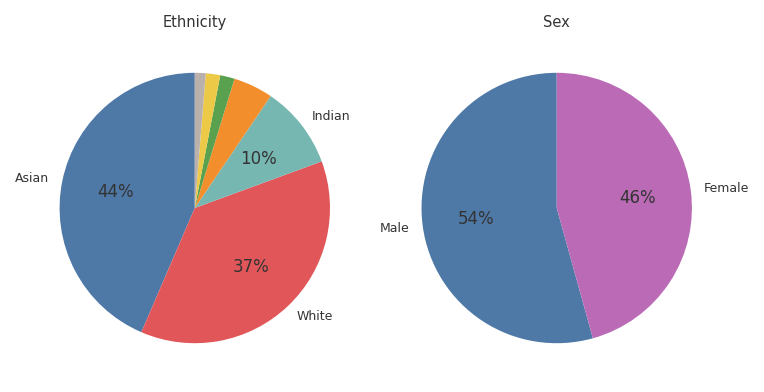

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5), layout="constrained")

# Pie: Ethnicity
eth_counts = wgd_labels["ethnicity"].value_counts()
eth_total = eth_counts.sum()
eth_pcts = eth_counts / eth_total
eth_colors = {
    "Asian": "#4E79A7", "White": "#E15759", "Indian": "#76B7B2",
    "Hispanic": "#F28E2B", "Black": "#59A14F", "Middle Eastern": "#EDC948",
    "Other": "#BAB0AC",
}
eth_c = [eth_colors.get(e, "#BAB0AC") for e in eth_counts.index]
eth_labels = [e if eth_pcts[e] >= 0.05 else "" for e in eth_counts.index]
axes[0].pie(eth_counts, labels=eth_labels, colors=eth_c, startangle=90,
            autopct=lambda p: f"{p:.0f}%" if p >= 9 else "")
axes[0].set_title("Ethnicity")

# Pie: Sex
sex_counts = wgd_labels["sex"].value_counts()
axes[1].pie(sex_counts, labels=sex_counts.index, autopct="%1.0f%%", startangle=90,
            colors=["#4E79A7", "#BB6BB6"])
axes[1].set_title("Sex")

fig.savefig(f"{FIGURES_PATH}/wgd_demographics.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# RQ 1)
# Score WGD
# WGD Calibration: correct if |Answer - true_weight| <= within_lbs

wgd_df["Answer_num"] = pd.to_numeric(wgd_df["Answer"], errors="coerce")
wgd_df = wgd_df.dropna(subset=["Answer_num"])
wgd_df["correct"] = (np.abs(wgd_df["Answer_num"] - wgd_df["true_weight"]) <= wgd_df["within_lbs"]).astype(int)

# LifeEval

In [6]:
df = pd.DataFrame()
le_path = RESULTS_PATH / Path("LifeEval")
for model in MODELS:
    new_df_path = le_path / Path(f"{model}.csv")
    new_df = pd.read_csv(new_df_path)
    new_df["model"] = model
    df = pd.concat([df, new_df])
    
df.reset_index(inplace = True)
df.tail()

,index,question_id,Answer,Confidence,raw,error,true_lifespan,min_age,sex,radius,...,sex_x,radius_x,best_answer_x,MAS_x,true_lifespan_y,min_age_y,sex_y,radius_y,best_answer_y,MAS_y
16155,4035,4035,102,0.78,"{""Answer"":""102"",""Confidence"":""0.78""}",NaN,102.14,100.0,female,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16156,4036,4036,103,0.72,"{""Answer"":""103"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16157,4037,4037,101,0.72,"{""Answer"":""101"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16158,4038,4038,101,0.72,"{""Answer"":""101"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16159,4039,4039,103,0.72,"{""Answer"":""103"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# RQ 1)
# LifeEval Calibration: true_probability from the empirical SSA life-table rule

from scoring import lifeeval_true_probability

LIFEEVAL_COLS = ["question_id", "Answer", "Confidence", "raw", "error",
                 "true_lifespan", "min_age", "sex", "radius", "best_answer", "MAS"]

le_df = pd.DataFrame()
le_path = RESULTS_PATH / Path("LifeEval")
for model in MODELS:
    new_df = pd.read_csv(le_path / f"{model}.csv")
    # Normalize mangled _x/_y columns from prior double-merges
    rename = {}
    for col in LIFEEVAL_COLS:
        if col not in new_df.columns and f"{col}_x" in new_df.columns:
            rename[f"{col}_x"] = col
    if rename:
        new_df = new_df.rename(columns=rename)
    new_df = new_df[[c for c in LIFEEVAL_COLS if c in new_df.columns] + ["model"] if "model" in new_df.columns else [c for c in LIFEEVAL_COLS if c in new_df.columns]]
    new_df["model"] = model
    le_df = pd.concat([le_df, new_df], ignore_index=True)

le_df["Answer_num"] = pd.to_numeric(le_df["Answer"], errors="coerce")
le_df = le_df.dropna(subset=["Answer_num", "sex", "min_age", "radius"])
le_df["true_probability"] = [
    lifeeval_true_probability(a, age, sex, r)
    for a, age, sex, r in zip(le_df["Answer_num"], le_df["min_age"], le_df["sex"], le_df["radius"])
]

# MedEval

In [8]:
df = pd.DataFrame()
me_path = RESULTS_PATH / Path("MedEval")
for model in MODELS:
    new_df_path = me_path / Path(f"{model}.csv")
    new_df = pd.read_csv(new_df_path)
    new_df["model"] = model
    df = pd.concat([df, new_df])
    
df.reset_index(inplace = True)
df.tail()

,index,question_id,Answer,Confidence,raw,error,age,sex,true_pathology,differential_json,removal_pct,model
3067,763,med_test_00187_c50,Acute COPD exacerbation / infection,0.97,"{""Answer"":""Acute COPD exacerbation / infection...",NaN,58,F,Acute COPD exacerbation / infection,"[[""Acute COPD exacerbation / infection"", 0.186...",50,openai_gpt-5.4-mini
3068,764,med_test_00188_c50,Anemia,0.99,"{""Answer"":""Anemia"",""Confidence"":""0.99""}",NaN,57,M,Anemia,"[[""Anemia"", 0.2686162167021044], [""Possible NS...",50,openai_gpt-5.4-mini
3069,765,med_test_00189_c50,Possible NSTEMI / STEMI,0.93,"{""Answer"":""Possible NSTEMI / STEMI"",""Confidenc...",NaN,26,F,Unstable angina,"[[""Possible NSTEMI / STEMI"", 0.297243036937004...",50,openai_gpt-5.4-mini
3070,766,med_test_00190_c50,Anemia,0.99,"{""Answer"":""Anemia"",""Confidence"":""0.99""}",NaN,21,F,Anemia,"[[""Anemia"", 0.25867387935973424], [""Atrial fib...",50,openai_gpt-5.4-mini
3071,767,med_test_00191_c50,Acute dystonic reactions,0.99,"{""Answer"":""Acute dystonic reactions"",""Confiden...",NaN,69,F,Acute dystonic reactions,"[[""Acute dystonic reactions"", 0.29503904274957...",50,openai_gpt-5.4-mini


In [9]:
# RQ 1)
# MedEval Calibration: true_probability via DDXPlus differential distribution
from scoring import medeval_true_probability

me_df = pd.DataFrame()
me_path = RESULTS_PATH / Path("MedEval")
for model in MODELS:
    new_df = pd.read_csv(me_path / f"{model}.csv")
    new_df["model"] = model
    me_df = pd.concat([me_df, new_df], ignore_index=True)

me_df["correct"] = (me_df["Answer"].str.strip().str.lower() == me_df["true_pathology"].str.strip().str.lower()).astype(int)
me_df["true_probability"] = [
    medeval_true_probability(a, d)
    for a, d in zip(me_df["Answer"], me_df["differential_json"])
]

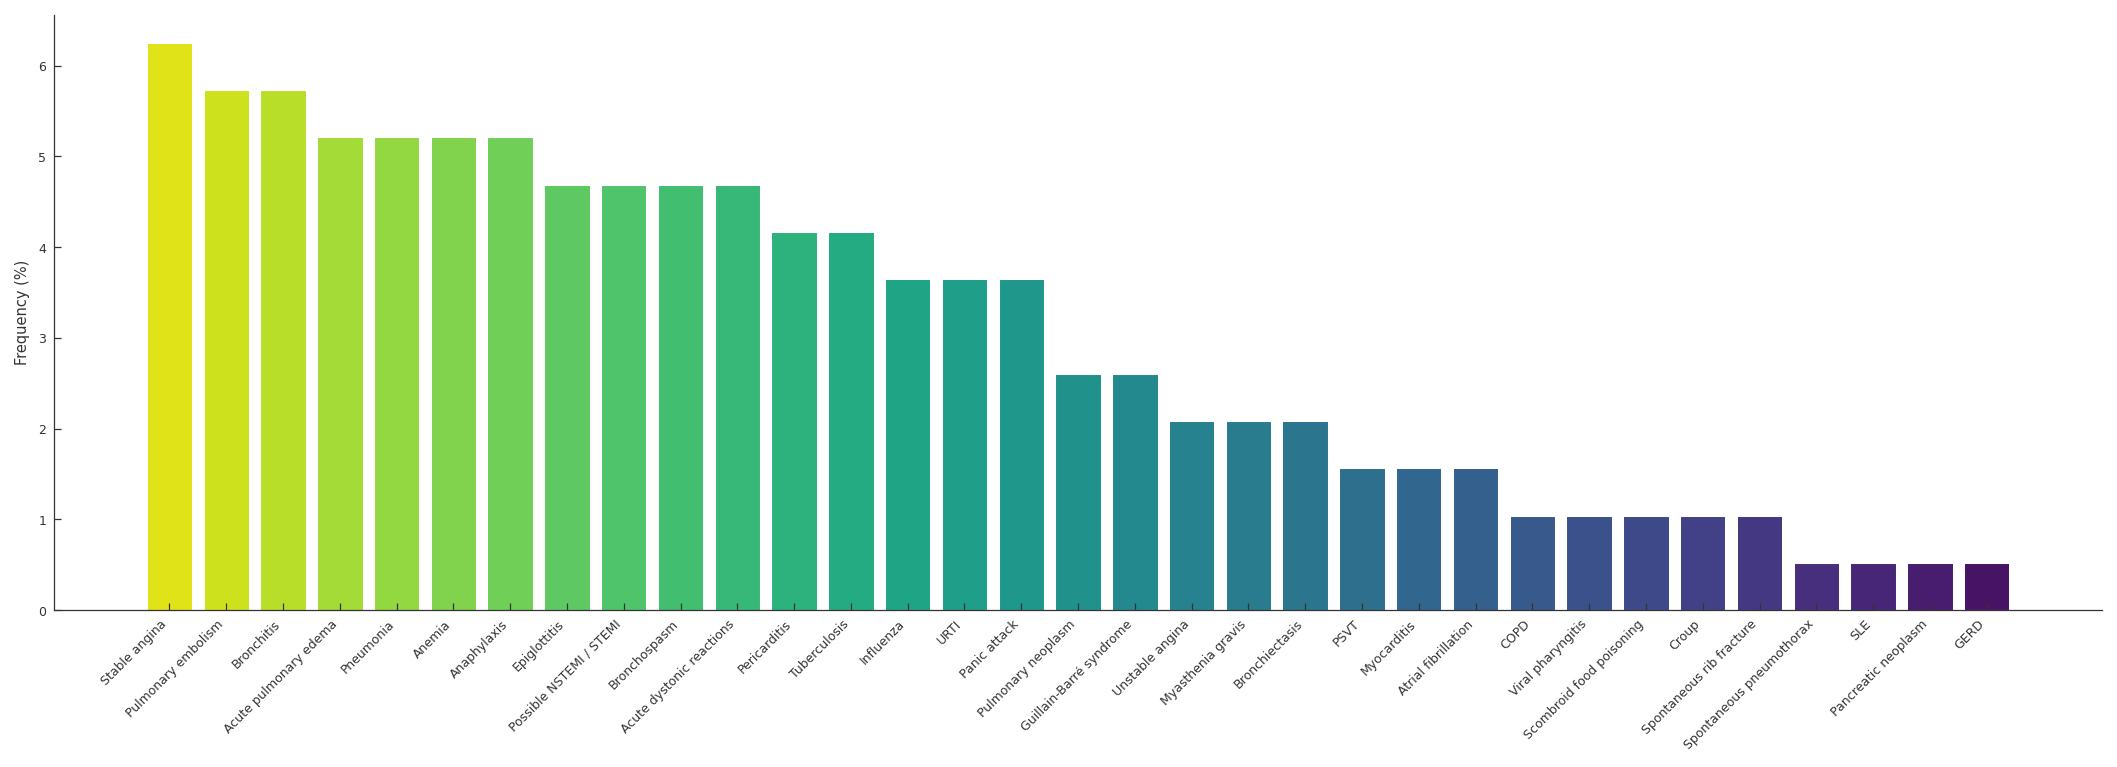

In [10]:
# MedEval: Pathology frequency distribution
import matplotlib.cm as mcm

bench_full = pd.read_csv(ROOT_DIR / "domains" / "MedEval" / "Data" / "benchmark_combined.csv")
bench_full = bench_full[bench_full["removal_pct"] == 0]
counts = bench_full["true_pathology"].value_counts()
counts = counts.rename({
    "Bronchospasm / acute asthma exacerbation": "Bronchospasm",
    "Acute COPD exacerbation / infection": "COPD",
})
pcts = counts / counts.sum() * 100
colors_path = mcm.viridis(np.linspace(0.95, 0.05, len(pcts)))

fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")
ax.bar(range(len(pcts)), pcts.values, color=colors_path, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(pcts)))
ax.set_xticklabels(pcts.index, rotation=45, ha="right")
ax.set_ylabel("Frequency (%)")

POSTER_PATH = Path(FIGURES_PATH) / "poster"
POSTER_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(POSTER_PATH / "medeval_pathologies.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
me_df[me_df["removal_pct"] == 50]

,question_id,Answer,Confidence,raw,error,age,sex,true_pathology,differential_json,removal_pct,model,correct,true_probability
576,med_test_00000_c50,Pulmonary neoplasm,0.82,"```json\n{""Answer"": ""Pulmonary neoplasm"", ""Con...",NaN,51,M,Pulmonary neoplasm,"[[""Pulmonary neoplasm"", 0.15298452862735284], ...",50,anthropic_claude-haiku-4.5,1,0.152985
577,med_test_00001_c50,Possible NSTEMI / STEMI,0.92,"```json\n{""Answer"": ""Possible NSTEMI / STEMI"",...",NaN,49,M,Stable angina,"[[""Possible NSTEMI / STEMI"", 0.195650109361549...",50,anthropic_claude-haiku-4.5,0,0.195650
578,med_test_00002_c50,Possible NSTEMI / STEMI,0.85,"```json\n{""Answer"": ""Possible NSTEMI / STEMI"",...",NaN,34,F,Stable angina,"[[""SLE"", 0.18008947852833548], [""Possible NSTE...",50,anthropic_claude-haiku-4.5,0,0.166795
579,med_test_00003_c50,Pericarditis,0.72,"```json\n{""Answer"": ""Pericarditis"", ""Confidenc...",NaN,29,M,Acute pulmonary edema,"[[""Acute pulmonary edema"", 0.12888117554815812...",50,anthropic_claude-haiku-4.5,0,0.098031
580,med_test_00004_c50,HIV (initial infection),0.78,"```json\n{""Answer"": ""HIV (initial infection)"",...",NaN,49,M,Influenza,"[[""Influenza"", 0.26988885591145373], [""Bronchi...",50,anthropic_claude-haiku-4.5,0,0.187450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,med_test_00187_c50,Acute COPD exacerbation / infection,0.97,"{""Answer"":""Acute COPD exacerbation / infection...",NaN,58,F,Acute COPD exacerbation / infection,"[[""Acute COPD exacerbation / infection"", 0.186...",50,openai_gpt-5.4-mini,1,0.186117
3068,med_test_00188_c50,Anemia,0.99,"{""Answer"":""Anemia"",""Confidence"":""0.99""}",NaN,57,M,Anemia,"[[""Anemia"", 0.2686162167021044], [""Possible NS...",50,openai_gpt-5.4-mini,1,0.268616
3069,med_test_00189_c50,Possible NSTEMI / STEMI,0.93,"{""Answer"":""Possible NSTEMI / STEMI"",""Confidenc...",NaN,26,F,Unstable angina,"[[""Possible NSTEMI / STEMI"", 0.297243036937004...",50,openai_gpt-5.4-mini,0,0.297243
3070,med_test_00190_c50,Anemia,0.99,"{""Answer"":""Anemia"",""Confidence"":""0.99""}",NaN,21,F,Anemia,"[[""Anemia"", 0.25867387935973424], [""Atrial fib...",50,openai_gpt-5.4-mini,1,0.258674


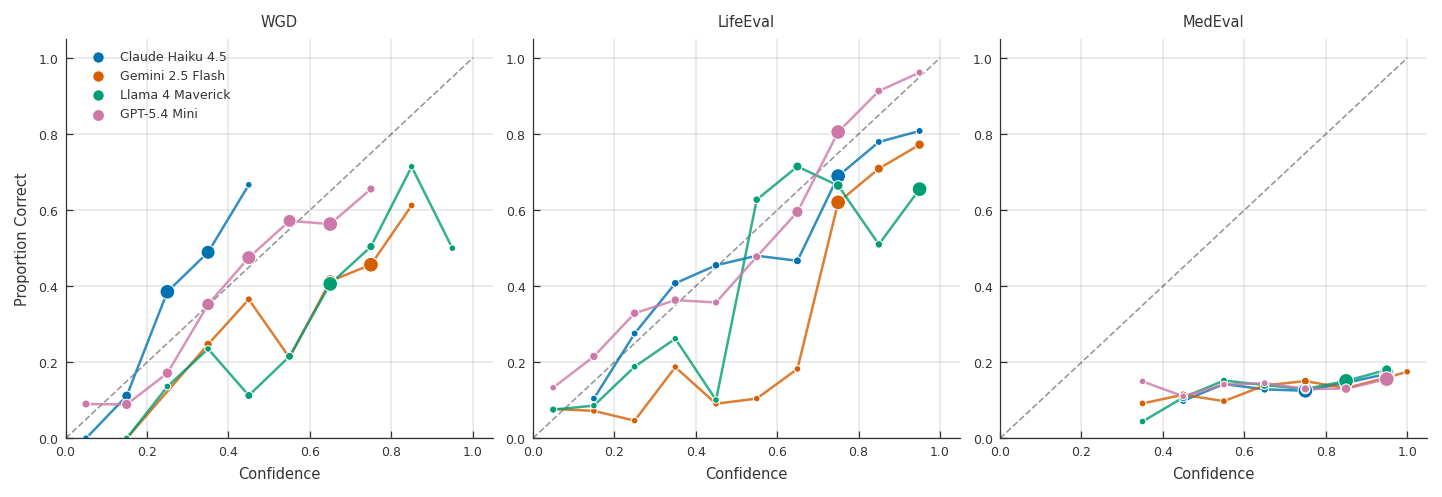

In [12]:
# RQ 1) Combined calibration plot
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), layout="constrained")

calibration_plot(axes[0], wgd_df, "correct", "WGD")
calibration_plot(axes[1], le_df, "true_probability", "LifeEval")
calibration_plot(axes[2], me_df, "true_probability", "MedEval")

for ax in axes:
    ax.set_aspect("auto")
for ax in axes[1:]:
    ax.set_ylabel("")

axes[0].set_ylabel("Proportion Correct")
axes[0].legend(bbox_to_anchor=(0.02, 1), loc="upper left")
Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/calibration_combined.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# RQ 1) Summary table: Accuracy, Mean Confidence, ECE by Domain × Model

from scoring import medeval_true_probability

def compute_ece(conf, outcome, bin_edges=BIN_EDGES):
    bins = pd.cut(conf, bins=bin_edges, right=False, include_lowest=True)
    grouped = pd.DataFrame({"conf": conf.values, "outcome": outcome.values, "bin": bins.values}).groupby("bin", observed=False)
    n = grouped.size()
    total = n.sum()
    if total == 0:
        return np.nan
    acc_per_bin = grouped["outcome"].mean()
    conf_per_bin = grouped["conf"].mean()
    return (n / total * (acc_per_bin - conf_per_bin).abs()).sum()

# Compute true_probability for MedEval if not already present
if "true_probability" not in me_df.columns:
    me_df["true_probability"] = [
        medeval_true_probability(a, d)
        for a, d in zip(me_df["Answer"], me_df["differential_json"])
    ]

rows = []
for domain, ddf, outcome_col in [
    ("WGD", wgd_df, "correct"),
    ("LifeEval", le_df, "true_probability"),
    ("MedEval", me_df, "true_probability"),
]:
    for model, label in zip(MODELS, MODEL_LABELS):
        sub = ddf[ddf["model"] == model]
        mean_conf = sub["Confidence"].mean()
        mean_acc = sub[outcome_col].mean()
        rows.append({
            "Domain": domain,
            "Model": label,
            "Accuracy": mean_acc,
            "Mean Confidence": mean_conf,
            "Overconfidence": mean_conf - mean_acc,
            "ECE": compute_ece(sub["Confidence"], sub[outcome_col]),
        })

summary = pd.DataFrame(rows).set_index(["Domain", "Model"])
summary.style.format("{:.3f}")

# RQ 2) Overconfidence by Task Difficulty

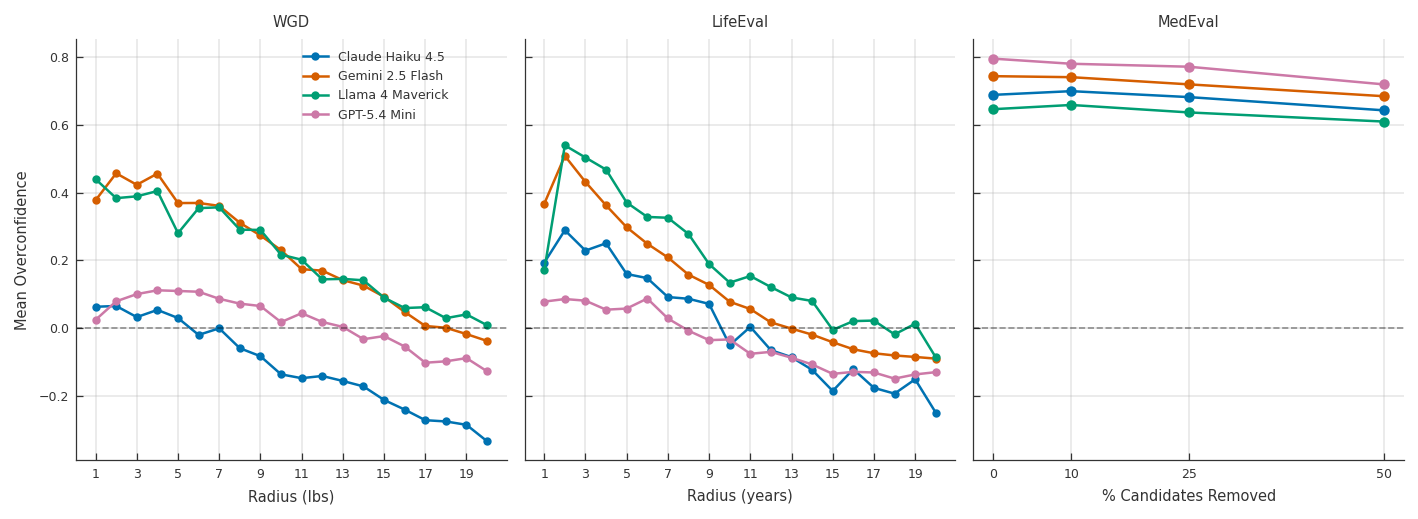

In [14]:
# RQ 2) Overconfidence by difficulty
# WGD: true_probability is binary (correct), difficulty = within_lbs
# LifeEval: true_probability from the empirical life table, difficulty = radius
# MedEval: true_probability via differential lookup, difficulty = removal_pct

from scoring import medeval_true_probability

# --- Compute overconfidence for each domain ---
wgd_df["overconfidence"] = wgd_df["Confidence"] - wgd_df["correct"]

le_df["overconfidence"] = le_df["Confidence"] - le_df["true_probability"]

me_df["true_probability"] = [
    medeval_true_probability(a, d)
    for a, d in zip(me_df["Answer"], me_df["differential_json"])
]
me_df["overconfidence"] = me_df["Confidence"] - me_df["true_probability"]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.5), sharey=True)

# WGD
ax = axes[0]
for model, label in zip(MODELS, MODEL_LABELS):
    sub = wgd_df[wgd_df["model"] == model]
    grouped = sub.groupby("within_lbs")["overconfidence"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", markersize=3,
            label=label, color=MODEL_COLORS[model], linewidth=1.2)
ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax.set_xlabel("Radius (lbs)")
ax.set_ylabel("Mean Overconfidence")
ax.set_title("WGD")
ax.set_xticks(range(1, 21, 2))
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

# LifeEval
ax = axes[1]
for model, label in zip(MODELS, MODEL_LABELS):
    sub = le_df[le_df["model"] == model]
    grouped = sub.groupby("radius")["overconfidence"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", markersize=3,
            label=label, color=MODEL_COLORS[model], linewidth=1.2)
ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax.set_xlabel("Radius (years)")
ax.set_title("LifeEval")
ax.set_xticks(range(1, 21, 2))
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

# MedEval
ax = axes[2]
for model, label in zip(MODELS, MODEL_LABELS):
    sub = me_df[me_df["model"] == model]
    grouped = sub.groupby("removal_pct")["overconfidence"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", markersize=4,
            label=label, color=MODEL_COLORS[model], linewidth=1.2)
ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax.set_xlabel("% Candidates Removed")
ax.set_title("MedEval")
ax.set_xticks([0, 10, 25, 50])
ax.grid(alpha=0.3)
ax.set_axisbelow(True)


plt.tight_layout()
axes[0].legend(bbox_to_anchor=(0.5, 1), loc="upper left")
Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/overconfidence_by_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()

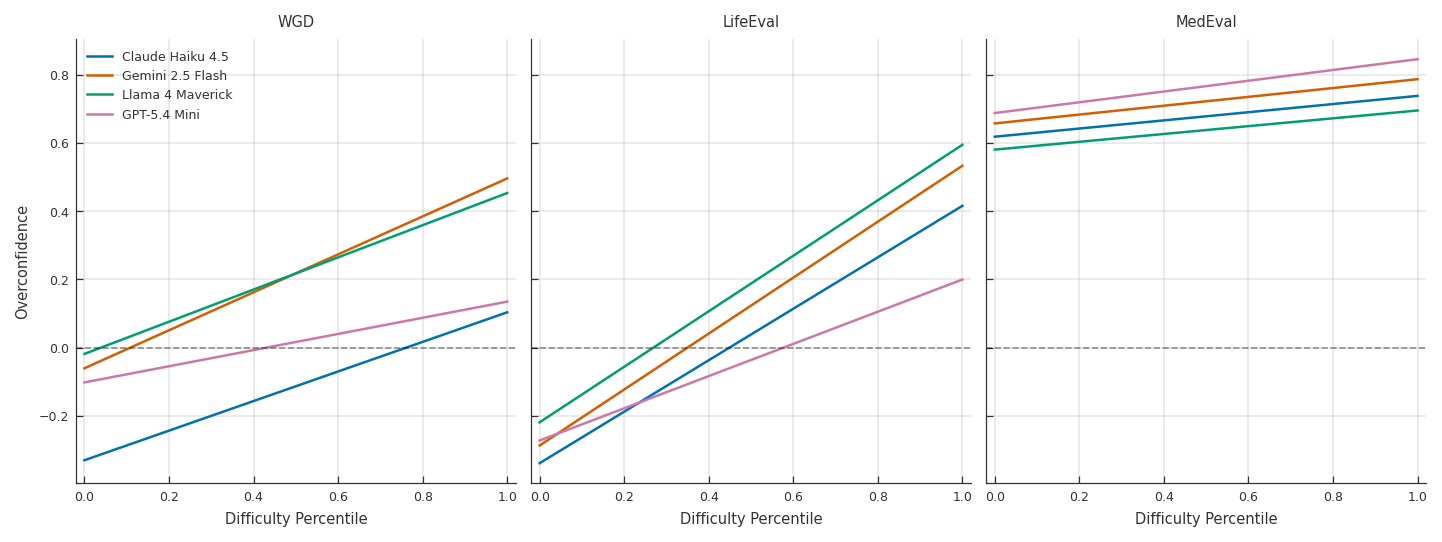

In [15]:
# RQ 2) Overconfidence vs. difficulty percentile (scatter + regression)
from evaluate_diff import add_difficulty
from scipy import stats as sp_stats

wgd_diff = add_difficulty(wgd_df, "WGD")
le_diff = add_difficulty(le_df, "LifeEval")
me_diff = add_difficulty(me_df, "MedEval")

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.5), sharey=True, layout="constrained")

for ax, title, ddf in [
    (axes[0], "WGD", wgd_diff),
    (axes[1], "LifeEval", le_diff),
    (axes[2], "MedEval", me_diff),
]:
    for model, label in zip(MODELS, MODEL_LABELS):
        sub = ddf[ddf["model"] == model].dropna(subset=["diff", "overconfidence"])
        # ax.scatter(sub["diff"], sub["overconfidence"], s=2, alpha=0.12,
        #            color=MODEL_COLORS[model], rasterized=True)
        slope, intercept, _, _, _ = sp_stats.linregress(sub["diff"], sub["overconfidence"])
        x_line = np.array([0, 1])
        ax.plot(x_line, intercept + slope * x_line, color=MODEL_COLORS[model],
                linewidth=1.2, label=label)
    ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.set_xlabel("Difficulty Percentile")
    ax.set_title(title)
    ax.set_xlim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Overconfidence")
axes[0].legend(loc="upper left")
fig.savefig(f"{FIGURES_PATH}/rq2_overconfidence_by_percentile.png", dpi=300, bbox_inches="tight")
plt.show()

# RQ 3) Does prompting models to output SPDs improve calibration?

In [16]:
# # RQ 3) Illustration: Generic vs SPD prompting approach (LifeEval example)
# import json
# import re
# from scoring import _death_mass

# ILLUSTRATION_QID = 1004       # question_id from LifeEval benchmark
# ILLUSTRATION_MODEL = MODELS[0]  # model to use for the example
# ILLUSTRATION_BIN_WIDTH = 10   # SPD bin width (must be in {2, 10, 20, 40})

# _JSON_ARRAY_RE = re.compile(r"\[.*\]", re.DOTALL)

# def parse_all_bins(raw):
#     if not raw or (isinstance(raw, float) and np.isnan(raw)):
#         return []
#     match = _JSON_ARRAY_RE.search(str(raw))
#     if not match:
#         return []
#     try:
#         arr = json.loads(match.group(0))
#     except json.JSONDecodeError:
#         return []
#     bins = []
#     for item in arr:
#         if not isinstance(item, dict):
#             continue
#         try:
#             lo, hi, conf = float(item["min"]), float(item["max"]), float(item["confidence"])
#         except (KeyError, TypeError, ValueError):
#             continue
#         if hi > lo:
#             bins.append((lo, hi, conf))
#     return sorted(bins, key=lambda b: b[0])

# # Load question metadata
# bench = pd.read_csv(ROOT_DIR / "domains" / "LifeEval" / "Data" / "benchmark.csv")
# q_row = bench[bench["question_id"] == ILLUSTRATION_QID].iloc[0]
# min_age, sex, radius = int(q_row["min_age"]), q_row["sex"], int(q_row["radius"])

# # Load generic result
# gen_df = pd.read_csv(RESULTS_PATH / "LifeEval" / f"{ILLUSTRATION_MODEL}.csv")
# gen_row = gen_df[gen_df["question_id"] == ILLUSTRATION_QID].iloc[0]
# gen_answer = float(gen_row["Answer"])

# # Load SPD result
# spd_qid = f"le_spd_{min_age}_{sex}_{ILLUSTRATION_BIN_WIDTH}"
# spd_df_ill = pd.read_csv(RESULTS_PATH / "LifeEval_SPD" / f"{ILLUSTRATION_MODEL}.csv")
# spd_row = spd_df_ill[spd_df_ill["question_id"] == spd_qid].iloc[0]
# bins_ill = parse_all_bins(spd_row["raw"])

# # Empirical conditional death probabilities (per-year mass from the SSA table)
# d_mass, m0, table_max = _death_mass(sex, min_age)
# x_pdf = np.arange(m0, table_max + 1)
# pdf = d_mass
# modal_idx = max(range(len(bins_ill)), key=lambda i: bins_ill[i][2])

# all_edges = [b[0] for b in bins_ill] + [b[1] for b in bins_ill] + [gen_answer - radius, gen_answer + radius]
# xlim = (min(min(all_edges), x_pdf[0]) - 2, max(max(all_edges), x_pdf[-1]) + 2)
# ylim = (0, max(pdf) * 1.1)

# POSTER_PATH = Path(FIGURES_PATH) / "poster"
# POSTER_PATH.mkdir(parents=True, exist_ok=True)

# # --- Generic plot ---
# fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
# ax.plot(x_pdf, pdf, color="#333333", linewidth=1.5, zorder=3, drawstyle="steps-post")
# ax.fill_between(x_pdf, pdf, alpha=0.06, color="#333333", zorder=1, step="post")
# win_lo = max(gen_answer - radius, min_age)
# win_hi = gen_answer + radius
# mask = (x_pdf >= win_lo) & (x_pdf <= win_hi)
# ax.fill_between(x_pdf[mask], pdf[mask], alpha=0.45, color="#FFD700", zorder=2, step="post")
# ax.axvline(gen_answer, color="#D32F2F", linewidth=2, zorder=4)
# ax.set_xlabel("Age at death (years)")
# ax.set_ylabel("P(death in [x, x+1))")
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# fig.savefig(POSTER_PATH / "generic_vs_spd_generic.png", dpi=300, bbox_inches="tight")
# plt.show()

# # --- SPD plot ---
# fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
# ax.plot(x_pdf, pdf, color="#333333", linewidth=1.5, zorder=3, drawstyle="steps-post")
# ax.fill_between(x_pdf, pdf, alpha=0.06, color="#333333", zorder=1, step="post")
# for i, (lo, hi, conf) in enumerate(bins_ill):
#     density = conf / (hi - lo)
#     is_modal = i == modal_idx
#     color = "#FFD700" if is_modal else "#89CFF0"
#     alpha = 0.7 if is_modal else 0.5
#     ax.bar((lo + hi) / 2, density, width=(hi - lo), alpha=alpha,
#            color=color, edgecolor="white", linewidth=0.5, zorder=2)
# ax.set_xlabel("Age at death (years)")
# ax.set_ylabel("P(death in [x, x+1))")
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# fig.savefig(POSTER_PATH / "generic_vs_spd_spd.png", dpi=300, bbox_inches="tight")
# plt.show()

In [17]:
# RQ 3) ECE improvement from SPD prompting
# Load SPD results and compute ECE_baseline vs ECE_spd per model per domain

from scoring import lifeeval_true_probability, medeval_true_probability

# --- Load SPD results ---

# WGD SPD
wgd_spd_df = pd.DataFrame()
for model in MODELS:
    new_df = pd.read_csv(RESULTS_PATH / "WGD_SPD" / f"{model}.csv")
    new_df["model"] = model
    wgd_spd_df = pd.concat([wgd_spd_df, new_df], ignore_index=True)
# Drop photo 269.jpg: present only in the SPD build (labeling error), not in the DCE set
wgd_spd_df = wgd_spd_df[wgd_spd_df["photo"] != "269.jpg"]
wgd_spd_df["Answer_num"] = pd.to_numeric(wgd_spd_df["Answer"], errors="coerce")
wgd_spd_df = wgd_spd_df.dropna(subset=["Answer_num"])
wgd_spd_df["correct"] = (np.abs(wgd_spd_df["Answer_num"] - wgd_spd_df["true_weight"]) <= wgd_spd_df["within_lbs"]).astype(int)

# LifeEval SPD
le_spd_df = pd.DataFrame()
for model in MODELS:
    new_df = pd.read_csv(RESULTS_PATH / "LifeEval_SPD" / f"{model}.csv")
    new_df["model"] = model
    le_spd_df = pd.concat([le_spd_df, new_df], ignore_index=True)
le_spd_df["Answer_num"] = pd.to_numeric(le_spd_df["Answer"], errors="coerce")
le_spd_df = le_spd_df.dropna(subset=["Answer_num", "sex", "min_age", "radius"])
le_spd_df["true_probability"] = [
    lifeeval_true_probability(a, age, sex, r)
    for a, age, sex, r in zip(le_spd_df["Answer_num"], le_spd_df["min_age"], le_spd_df["sex"], le_spd_df["radius"])
]

# MedEval SPD
me_spd_df = pd.DataFrame()
for model in MODELS:
    new_df = pd.read_csv(RESULTS_PATH / "MedEval_SPD" / f"{model}.csv")
    new_df["model"] = model
    me_spd_df = pd.concat([me_spd_df, new_df], ignore_index=True)
me_spd_df["true_probability"] = [
    medeval_true_probability(a, d)
    for a, d in zip(me_spd_df["Answer"], me_spd_df["differential_json"])
]

# --- Compute ECE baseline vs SPD ---
rows_rq3 = []
for domain, base_df, spd_df, outcome_col in [
    ("WGD", wgd_df, wgd_spd_df, "correct"),
    ("LifeEval", le_df, le_spd_df, "true_probability"),
    ("MedEval", me_df, me_spd_df, "true_probability"),
]:
    for model, label in zip(MODELS, MODEL_LABELS):
        sub_base = base_df[base_df["model"] == model]
        sub_spd = spd_df[spd_df["model"] == model]
        ece_base = compute_ece(sub_base["Confidence"], sub_base[outcome_col])
        ece_spd = compute_ece(sub_spd["Confidence"], sub_spd[outcome_col])
        pct_change = (ece_spd - ece_base) / ece_base * 100 if ece_base != 0 else 0.0
        rows_rq3.append({
            "Domain": domain,
            "Model": label,
            "ECE": ece_base,
            "ECE_SPD": ece_spd,
            "Delta": ece_base - ece_spd,
            "Pct_Change": pct_change,
        })

rq3_df = pd.DataFrame(rows_rq3)
rq3_df.style.format({"ECE": "{:.4f}", "ECE_SPD": "{:.4f}", "Delta": "{:.4f}", "Pct_Change": "{:.1f}%"})

,Domain,Model,ECE,ECE_SPD,Delta,Pct_Change
0,WGD,Claude Haiku 4.5,0.1228,0.0811,0.0417,-34.0%
1,WGD,Gemini 2.5 Flash,0.2170,0.0717,0.1453,-67.0%
2,WGD,Llama 4 Maverick,0.2164,0.0736,0.1428,-66.0%
3,WGD,GPT-5.4 Mini,0.0461,0.0871,-0.0410,89.0%
4,LifeEval,Claude Haiku 4.5,0.0485,0.1626,-0.1141,235.5%
5,LifeEval,Gemini 2.5 Flash,0.1210,0.0990,0.0219,-18.1%
6,LifeEval,Llama 4 Maverick,0.2086,0.1715,0.0371,-17.8%
7,LifeEval,GPT-5.4 Mini,0.0564,0.0595,-0.0031,5.6%
8,MedEval,Claude Haiku 4.5,0.6777,0.3605,0.3173,-46.8%
9,MedEval,Gemini 2.5 Flash,0.7217,0.4196,0.3021,-41.9%


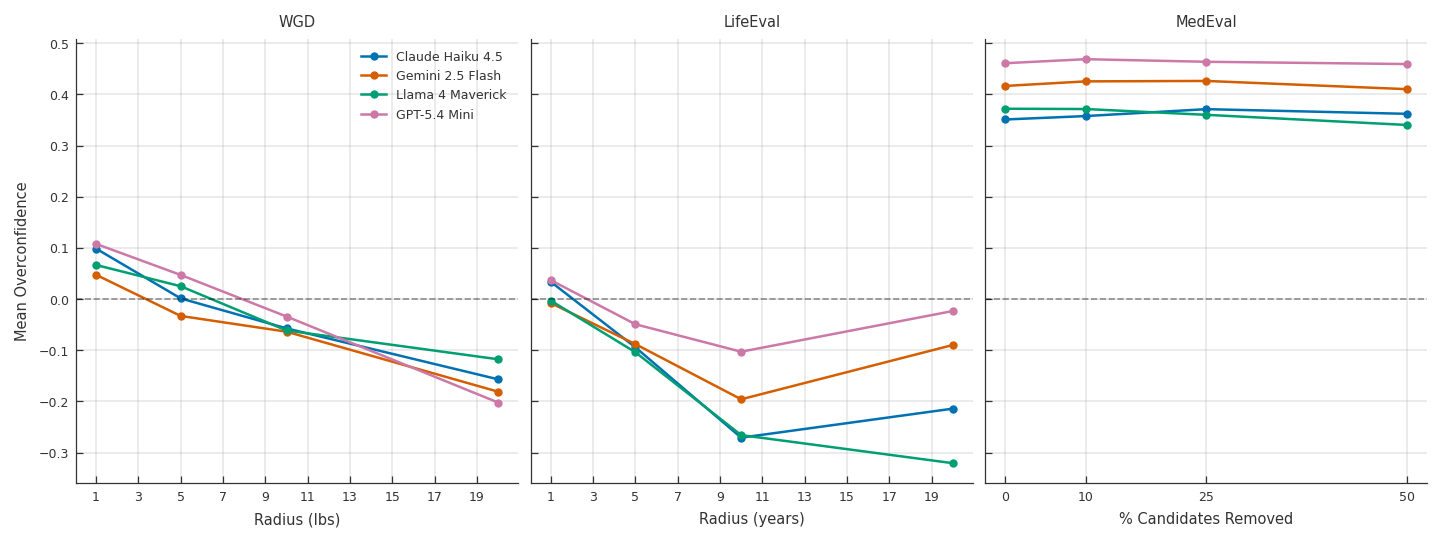

In [18]:
# RQ 3) Overconfidence by difficulty — SPD-prompted responses
wgd_spd_df["overconfidence"] = wgd_spd_df["Confidence"] - wgd_spd_df["correct"]
le_spd_df["overconfidence"] = le_spd_df["Confidence"] - le_spd_df["true_probability"]
me_spd_df["overconfidence"] = me_spd_df["Confidence"] - me_spd_df["true_probability"]

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.5), sharey=True, layout="constrained")

configs = [
    (axes[0], "WGD", wgd_spd_df, "within_lbs", "Radius (lbs)", range(1, 21, 2)),
    (axes[1], "LifeEval", le_spd_df, "radius", "Radius (years)", range(1, 21, 2)),
    (axes[2], "MedEval", me_spd_df, "removal_pct", "% Candidates Removed", [0, 10, 25, 50]),
]

for ax, title, spd_df, diff_col, xlabel, xticks in configs:
    for model, label in zip(MODELS, MODEL_LABELS):
        sub = spd_df[spd_df["model"] == model]
        grouped = sub.groupby(diff_col)["overconfidence"].mean()
        ax.plot(grouped.index, grouped.values, marker="o", markersize=3,
                color=MODEL_COLORS[model], linewidth=1.2, label=label)
    ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xticks(xticks)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Mean Overconfidence")
axes[0].legend(loc="upper right")

POSTER_PATH = Path(FIGURES_PATH) / "poster"
POSTER_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(POSTER_PATH / "overconfidence_by_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
MODELS, MODEL_LABELS


(['anthropic_claude-haiku-4.5',
  'google_gemini-2.5-flash',
  'meta-llama_llama-4-maverick',
  'openai_gpt-5.4-mini'],
 ['Claude Haiku 4.5', 'Gemini 2.5 Flash', 'Llama 4 Maverick', 'GPT-5.4 Mini'])

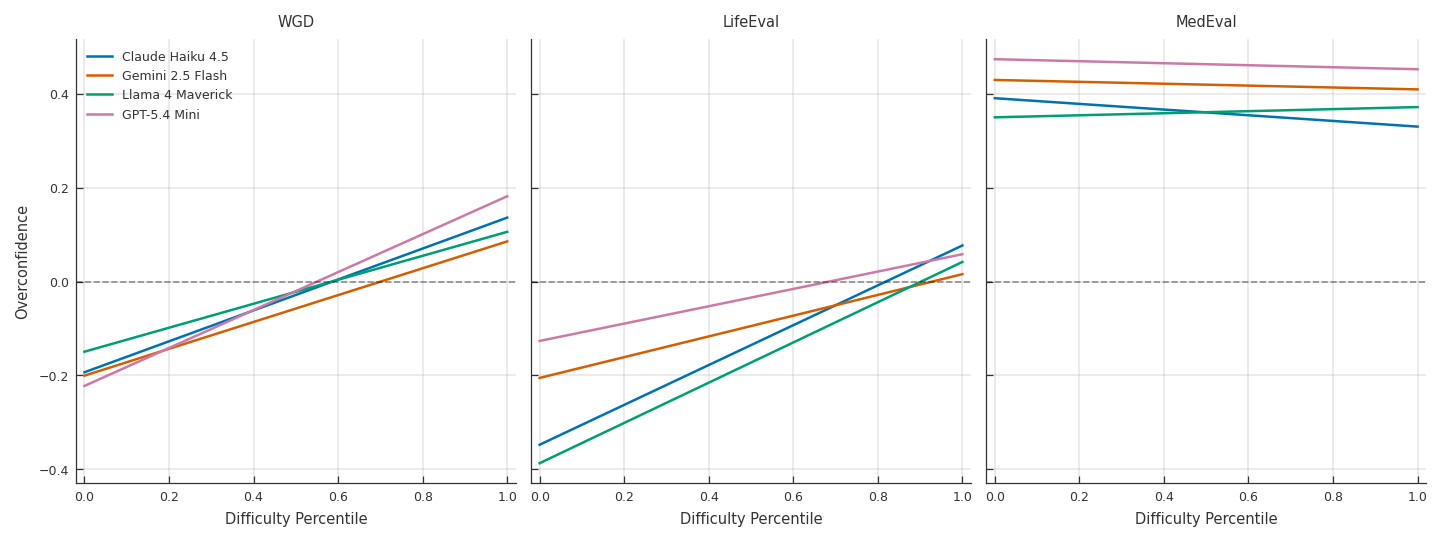

In [20]:
# RQ 3) Overconfidence vs. difficulty percentile — SPD-prompted responses
from evaluate_diff import add_difficulty
from scipy import stats as sp_stats

wgd_spd_diff = add_difficulty(wgd_spd_df, "WGD")
le_spd_diff = add_difficulty(le_spd_df, "LifeEval")
me_spd_diff = add_difficulty(me_spd_df, "MedEval")

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.5), sharey=True, layout="constrained")

for ax, title, ddf in [
    (axes[0], "WGD", wgd_spd_diff),
    (axes[1], "LifeEval", le_spd_diff),
    (axes[2], "MedEval", me_spd_diff),
]:
    for model, label in zip(MODELS, MODEL_LABELS):

        sub = ddf[ddf["model"] == model].dropna(subset=["diff", "overconfidence"])
        # ax.scatter(sub["diff"], sub["overconfidence"], s=2, alpha=0.12,
        #            color=MODEL_COLORS[model], rasterized=True)
        slope, intercept, _, _, _ = sp_stats.linregress(sub["diff"], sub["overconfidence"])
        x_line = np.array([0, 1])
        ax.plot(x_line, intercept + slope * x_line, color=MODEL_COLORS[model],
                linewidth=1.2, label=label)
    ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.set_xlabel("Difficulty Percentile")
    ax.set_title(title)
    ax.set_xlim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Overconfidence")
axes[0].legend(loc="upper left")
fig.savefig(f"{FIGURES_PATH}/rq3_overconfidence_by_percentile_spd.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
rq3_df.groupby("Domain").ECE.mean()

Domain
LifeEval    0.108603
MedEval     0.700742
WGD         0.150567
Name: ECE, dtype: float64

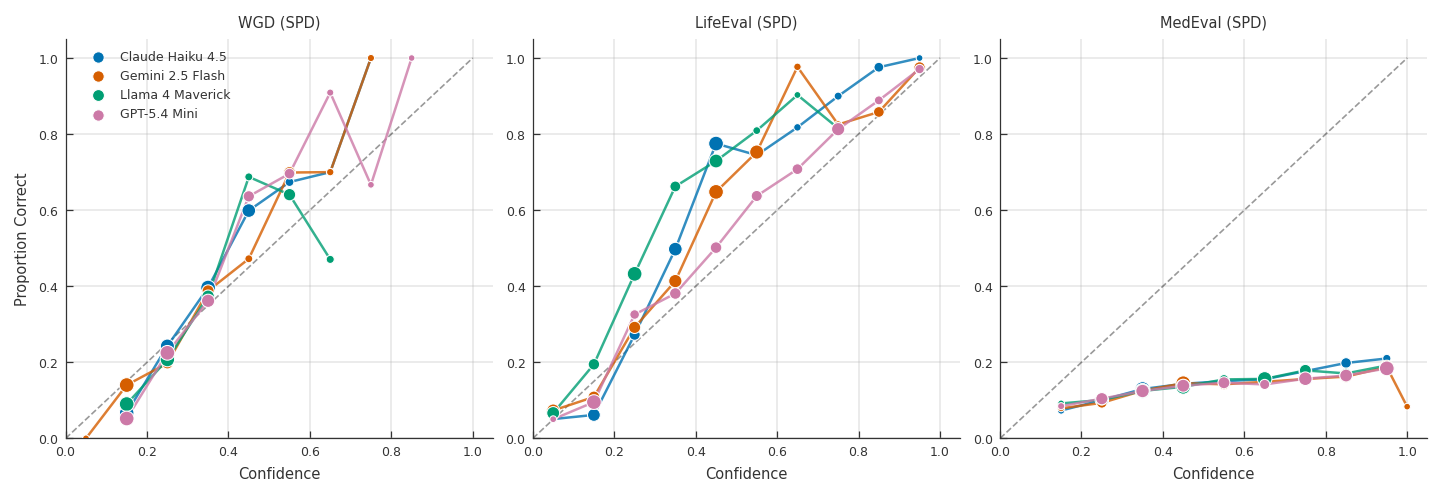

In [22]:
# RQ 3) Calibration plot for SPD-prompted responses
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), layout="constrained")

calibration_plot(axes[0], wgd_spd_df, "correct", "WGD (SPD)")
calibration_plot(axes[1], le_spd_df, "true_probability", "LifeEval (SPD)")
calibration_plot(axes[2], me_spd_df, "true_probability", "MedEval (SPD)") 

for ax in axes:
    ax.set_aspect("auto")
for ax in axes[1:]:
    ax.set_ylabel("")

axes[0].set_ylabel("Proportion Correct")
axes[0].legend(bbox_to_anchor=(0.02, 1), loc="upper left")
Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/calibration_spd_combined.png", dpi=300, bbox_inches="tight")
plt.show()

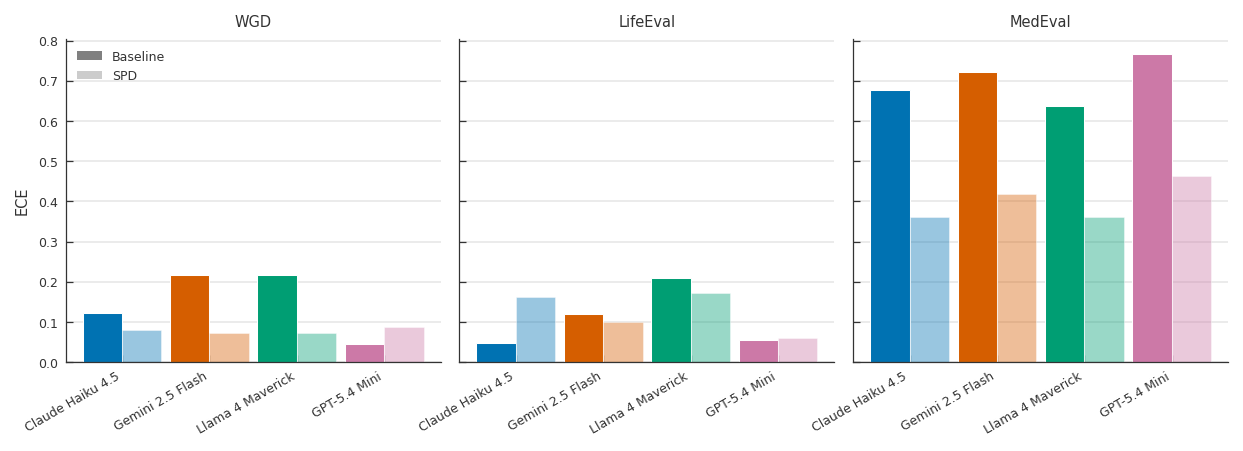

In [23]:
# RQ 3) Side-by-side ECE: Baseline vs SPD per model per domain
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), sharey= True)

domains = ["WGD", "LifeEval", "MedEval"]
x = np.arange(len(MODELS))
bar_width = 0.45

for idx, (ax, domain) in enumerate(zip(axes, domains)):
    sub = rq3_df[rq3_df["Domain"] == domain]
    ece_base = sub["ECE"].values
    ece_spd = sub["ECE_SPD"].values
    colors = [MODEL_COLORS[m] for m in MODELS]

    ax.bar(x - bar_width / 2, ece_base, bar_width, color=colors,
           edgecolor="white", linewidth=0.5)
    ax.bar(x + bar_width / 2, ece_spd, bar_width, color=colors,
           edgecolor="white", linewidth=0.5, alpha=0.4)

    ax.set_title(domain)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_LABELS, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("ECE")
handles = [plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=1.0), plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.4)]
axes[0].legend(handles, ["Baseline", "SPD"], loc="upper left")
plt.subplots_adjust(wspace  = 0.05)
# not saved: figs/rq3_ece_spd_improvement.png is written by the significance
# version in the next cell (same plot + bootstrap significance brackets)
plt.show()

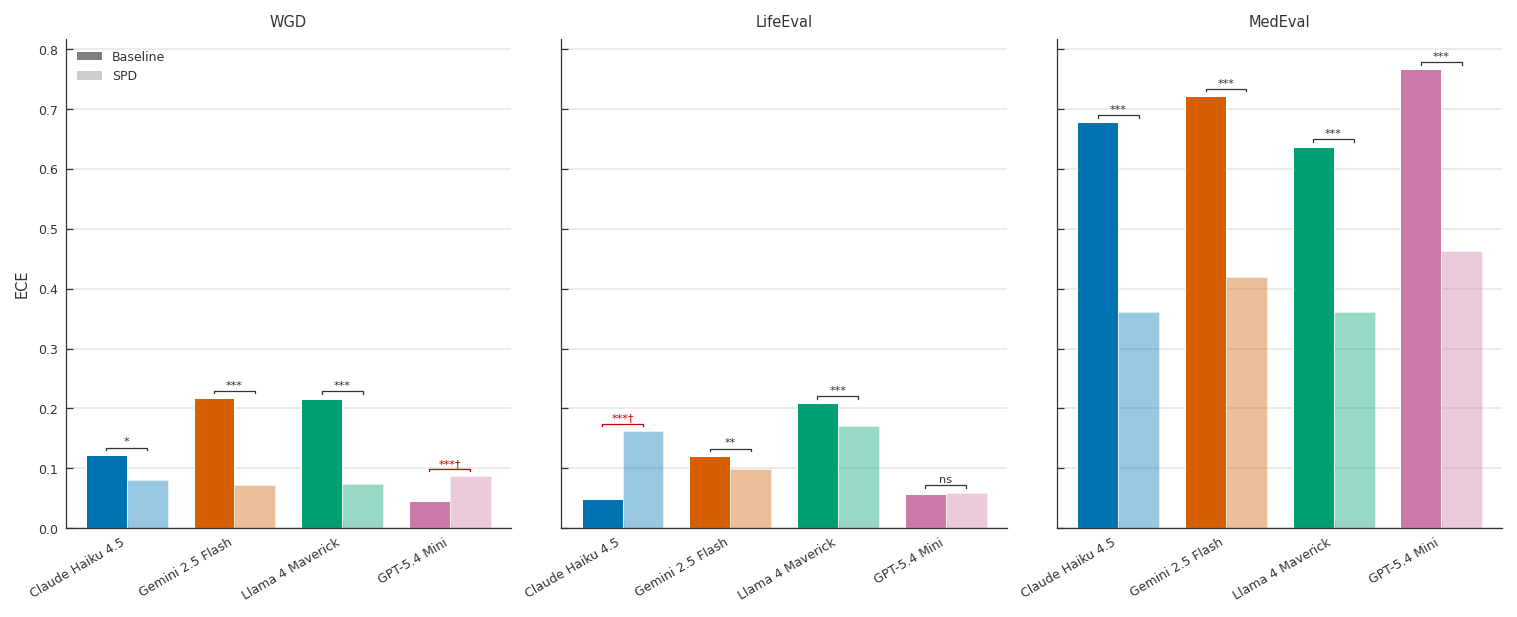

In [24]:
# RQ 3) ECE Baseline vs SPD with bootstrap significance brackets

OUTCOME_COLS_RQ3 = {"WGD": "correct", "LifeEval": "true_probability", "MedEval": "true_probability"}
base_dfs_rq3 = {"WGD": wgd_df, "LifeEval": le_df, "MedEval": me_df}
spd_dfs_rq3 = {"WGD": wgd_spd_df, "LifeEval": le_spd_df, "MedEval": me_spd_df}

def _bootstrap_ece(conf, outcome, n_boot=2000, rng=None):
    n = len(conf)
    conf_arr, out_arr = conf.values, outcome.values
    eces = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        eces[i] = compute_ece(pd.Series(conf_arr[idx]), pd.Series(out_arr[idx]))
    return eces

def _two_sided_p(boot_delta):
    p_lower = (boot_delta <= 0).mean()
    return 2 * min(p_lower, 1 - p_lower)

def _sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

rng_ece = np.random.default_rng(42)
ece_results = {}
for domain in ["WGD", "LifeEval", "MedEval"]:
    oc = OUTCOME_COLS_RQ3[domain]
    for model in MODELS:
        sb = base_dfs_rq3[domain][base_dfs_rq3[domain]["model"] == model].dropna(subset=["Confidence", oc])
        ss = spd_dfs_rq3[domain][spd_dfs_rq3[domain]["model"] == model].dropna(subset=["Confidence", oc])
        ece_base = compute_ece(sb["Confidence"], sb[oc])
        ece_spd = compute_ece(ss["Confidence"], ss[oc])
        boot_base = _bootstrap_ece(sb["Confidence"], sb[oc], rng=rng_ece)
        boot_spd = _bootstrap_ece(ss["Confidence"], ss[oc], rng=rng_ece)
        p_val = _two_sided_p(boot_base - boot_spd)
        ece_results[(domain, model)] = {
            "ece_base": ece_base, "ece_spd": ece_spd,
            "p": p_val, "direction": "better" if ece_spd < ece_base else "worse",
        }

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True, layout="constrained")
x = np.arange(len(MODELS))
bw = 0.38

for ax, domain in zip(axes, ["WGD", "LifeEval", "MedEval"]):
    ece_bases = [ece_results[(domain, m)]["ece_base"] for m in MODELS]
    ece_spds = [ece_results[(domain, m)]["ece_spd"] for m in MODELS]
    ax.bar(x - bw / 2, ece_bases, bw, color=CB_PALETTE, edgecolor="white", linewidth=0.5)
    ax.bar(x + bw / 2, ece_spds, bw, color=CB_PALETTE, edgecolor="white", linewidth=0.5, alpha=0.4)

    for i, model in enumerate(MODELS):
        r = ece_results[(domain, model)]
        p = r["p"]
        label = _sig_label(p)
        if label != "ns" and r["direction"] == "worse":
            label += "†"
        bar_top = max(r["ece_base"], r["ece_spd"])
        y = bar_top + 0.008
        bracket_color = "#CC0000" if (label != "ns" and r["direction"] == "worse") else "#333333"
        ax.plot([i - bw/2, i - bw/2, i + bw/2, i + bw/2],
                [y, y + 0.004, y + 0.004, y], color=bracket_color, linewidth=0.6)
        ax.text(i, y + 0.005, label, ha="center", va="bottom", fontsize=5.5, color=bracket_color)

    ax.set_title(domain)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_LABELS, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel("ECE")
handles = [plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=1.0),
           plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.4)]
axes[0].legend(handles, ["Baseline", "SPD"], loc="upper left")

Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/rq3_ece_spd_improvement.png", dpi=300, bbox_inches="tight")
POSTER_PATH = Path(FIGURES_PATH) / "poster"
POSTER_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(POSTER_PATH / "rq3_ece_significance.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Combined summary table with RQ1 + RQ2 (β₁) + RQ3 (ECE_SPD, ΔECE%)
# Includes bootstrap two-sided significance for both β₁ and ΔECE
# Exports LaTeX to rq1_summary_table.txt

from scipy import stats as sp_stats

from evaluate_diff import add_difficulty

OUTCOME_COLS = {"WGD": "correct", "LifeEval": "true_probability", "MedEval": "true_probability"}

def sig_label(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def bootstrap_ece(conf, outcome, n_boot=2000, rng=np.random.default_rng(42)):
    n = len(conf)
    conf_arr, out_arr = conf.values, outcome.values
    eces = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        eces[i] = compute_ece(pd.Series(conf_arr[idx]), pd.Series(out_arr[idx]))
    return eces

def two_sided_p(boot_delta):
    p_lower = (boot_delta <= 0).mean()
    return 2 * min(p_lower, 1 - p_lower)

# --- Build combined rows ---
base_dfs = {"WGD": wgd_df, "LifeEval": le_df, "MedEval": me_df}
spd_dfs = {"WGD": wgd_spd_df, "LifeEval": le_spd_df, "MedEval": me_spd_df}

rows_combined = []
rng = np.random.default_rng(42)
for domain in ["WGD", "LifeEval", "MedEval"]:
    ddf = base_dfs[domain]
    sdf = spd_dfs[domain]
    outcome_col = OUTCOME_COLS[domain]
    ddf_diff = add_difficulty(ddf, domain)
    for model, label in zip(MODELS, MODEL_LABELS):
        # RQ2: β₁ regression on difficulty percentile
        sub = ddf_diff[ddf_diff["model"] == model].dropna(subset=["diff", "overconfidence"])
        slope, _, _, p_beta, _ = sp_stats.linregress(sub["diff"], sub["overconfidence"])

        # RQ3: bootstrap significance of ΔECE
        sub_base = ddf[ddf["model"] == model].dropna(subset=["Confidence", outcome_col])
        sub_spd = sdf[sdf["model"] == model].dropna(subset=["Confidence", outcome_col])
        boot_base = bootstrap_ece(sub_base["Confidence"], sub_base[outcome_col], rng=rng)
        boot_spd = bootstrap_ece(sub_spd["Confidence"], sub_spd[outcome_col], rng=rng)
        p_ece = two_sided_p(boot_base - boot_spd)

        rq3_row = rq3_df[(rq3_df["Domain"] == domain) & (rq3_df["Model"] == label)].iloc[0]
        summary_row = summary.loc[(domain, label)]
        rows_combined.append({
            "Domain": domain,
            "Model": label,
            "Accuracy": summary_row["Accuracy"],
            "Mean Confidence": summary_row["Mean Confidence"],
            "Overconfidence": summary_row["Overconfidence"],
            "beta1": slope,
            "beta1_sig": sig_label(p_beta),
            "ECE": summary_row["ECE"],
            "ECE_SPD": rq3_row["ECE_SPD"],
            "Pct_Change": rq3_row["Pct_Change"],
            "ece_sig": sig_label(p_ece),
        })
        print(f"  {domain:10s} {label:20s}  β₁ p={p_beta:.2e}  ΔECE p={p_ece:.4f}")

combined = pd.DataFrame(rows_combined)

# --- Generate LaTeX ---
def fmt_signed(v, decimals=3):
    s = f"{abs(v):.{decimals}f}"
    return f"$-${s}" if v < 0 else f"$+${s}" if v > 0 else s

lines = [
    r"\begin{table}[t]",
    r"\centering",
    r"\caption{Summary of model calibration across domains. Accuracy denotes mean correctness (WGD) or mean true probability (LifeEval, MedEval). Overconfidence = Mean Confidence $-$ Accuracy. $\beta_1$ is the OLS slope of overconfidence on difficulty percentile. ECE\textsubscript{SPD} and $\Delta$ECE show the effect of subjective probability distribution prompting.}",
    r"\label{tab:rq1_summary}",
    r"\begin{tabular}{llccccccc}",
    r"\toprule",
    r"Domain & Model & Accuracy & Mean Conf. & Overconf. & $\beta_1$ & ECE & ECE\textsubscript{SPD} & $\Delta$ECE (\%) \\",
    r"\midrule",
]

for domain in ["WGD", "LifeEval", "MedEval"]:
    sub = combined[combined["Domain"] == domain]
    lines.append(rf"\multirow{{4}}{{*}}{{{domain}}}")
    for _, r in sub.iterrows():
        oc = fmt_signed(r["Overconfidence"])
        b1 = fmt_signed(r["beta1"])
        pct = fmt_signed(r["Pct_Change"], 1)
        lines.append(
            f" & {r['Model']:20s} & {r['Accuracy']:.3f} & {r['Mean Confidence']:.3f} "
            f"& {oc} & {b1}\\textsuperscript{{{r['beta1_sig']}}} "
            f"& {r['ECE']:.3f} & {r['ECE_SPD']:.3f} & {pct}\\textsuperscript{{{r['ece_sig']}}} \\\\"
        )
    if domain != "MedEval":
        lines.append(r"\midrule")

lines += [
    r"\bottomrule",
    r"\multicolumn{9}{l}{\footnotesize \textsuperscript{*}$p<0.05$, \textsuperscript{**}$p<0.01$, \textsuperscript{***}$p<0.001$} \\",
    r"\end{tabular}",
    r"\end{table}",
]

latex_str = "\n".join(lines)
Path("rq1_summary_table.txt").write_text(latex_str)
print("\nLaTeX written to rq1_summary_table.txt")
print(latex_str)

  WGD        Claude Haiku 4.5      β₁ p=2.21e-62  ΔECE p=0.0170


  WGD        Gemini 2.5 Flash      β₁ p=2.14e-111  ΔECE p=0.0000


  WGD        Llama 4 Maverick      β₁ p=2.30e-88  ΔECE p=0.0000


  WGD        GPT-5.4 Mini          β₁ p=1.47e-23  ΔECE p=0.0010


  LifeEval   Claude Haiku 4.5      β₁ p=0.00e+00  ΔECE p=0.0000


...

  LifeEval   GPT-5.4 Mini          β₁ p=0.00e+00  ΔECE p=0.5510


  MedEval    Claude Haiku 4.5      β₁ p=1.36e-22  ΔECE p=0.0000


  MedEval    Gemini 2.5 Flash      β₁ p=2.90e-14  ΔECE p=0.0000


  MedEval    Llama 4 Maverick      β₁ p=3.25e-12  ΔECE p=0.0000


  MedEval    GPT-5.4 Mini          β₁ p=1.65e-40  ΔECE p=0.0000

LaTeX written to rq1_summary_table.txt
\begin{table}[t]
\centering
\caption{Summary of model calibration across domains. Accuracy denotes mean correctness (WGD) or mean true probability (LifeEval, MedEval). Overconfidence = Mean Confidence $-$ Accuracy. $\beta_1$ is the OLS slope of overconfidence on difficulty percentile. ECE\textsubscript{SPD} and $\Delta$ECE show the effect of subjective probability distribution prompting.}
\label{tab:rq1_summary}
\begin{tabular}{llccccccc}
\toprule
Domain & Model & Accuracy & Mean Conf. & Overconf. & $\beta_1$ & ECE & ECE\textsubscript{SPD} & $\Delta$ECE (\%) \\
\midrule
\multirow{4}{*}{WGD}
 & Claude Haiku 4.5     & 0.385 & 0.274 & $-$0.111 & $+$0.433\textsuperscript{***} & 0.123 & 0.081 & $-$34.0\textsuperscript{*} \\
 & Gemini 2.5 Flash     & 0.421 & 0.638 & $+$0.217 & $+$0.556\textsuperscript{***} & 0.217 & 0.072 & $-$67.0\textsuperscript{***} \\
 & Llama 4 Maverick     & 0.372 & 

# Post Hoc Analysis

## Sex Bias in WGD Weight Estimates

Directional error: $\text{Error} = \text{Answer} - \text{true\_weight}$

Positive error means the model **overestimates** weight; negative means it **underestimates**.

We compute $\bar{E}_M - \bar{E}_F$ per model. A positive value means models overestimate men's weight more (or underestimate less) than women's.

In [26]:
from scipy import stats

wgd_labels = pd.read_csv(ROOT_DIR / "domains" / "WGD" / "Data" / "labels.csv")
wgd_labels = wgd_labels.dropna(subset=["sex"])

# Join sex onto results via photo filename <-> Participant Number (both as str)
wgd_bias = wgd_df.copy()
wgd_bias["participant"] = wgd_bias["photo"].str.replace(".jpg", "", regex=False)
sex_map = wgd_labels.set_index("Participant Number")["sex"]
wgd_bias["sex"] = wgd_bias["participant"].map(sex_map)
wgd_bias = wgd_bias.dropna(subset=["sex"])

# Directional error: positive = overestimate
wgd_bias["dir_error"] = wgd_bias["Answer_num"] - wgd_bias["true_weight"]

# Collapse to one error per (model, photo, sex) — average across within_lbs levels
# since within_lbs doesn't affect the point estimate
photo_error = wgd_bias.groupby(["model", "participant", "sex"])["dir_error"].mean().reset_index()

# --- Summary table ---
rows = []
for model, label in zip(MODELS, MODEL_LABELS):
    sub = photo_error[photo_error["model"] == model]
    err_m = sub.loc[sub["sex"] == "Male", "dir_error"]
    err_f = sub.loc[sub["sex"] == "Female", "dir_error"]
    delta = err_m.mean() - err_f.mean()
    t_stat, p_val = stats.ttest_ind(err_m, err_f, equal_var=False)
    # 95% CI for the difference via Welch's t
    n_m, n_f = len(err_m), len(err_f)
    se_diff = np.sqrt(err_m.var() / n_m + err_f.var() / n_f)
    df_welch = se_diff**4 / (
        (err_m.var() / n_m)**2 / (n_m - 1) + (err_f.var() / n_f)**2 / (n_f - 1)
    )
    ci95_delta = stats.t.ppf(0.975, df=df_welch) * se_diff
    rows.append({
        "Model": label,
        "Mean Error (Male)": err_m.mean(),
        "Mean Error (Female)": err_f.mean(),
        "Δ (M − F)": delta,
        "CI95 (Δ)": ci95_delta,
        "t": t_stat,
        "p-value": p_val,
        "n_male": n_m,
        "n_female": n_f,
    })

bias_df = pd.DataFrame(rows)
bias_df.style.format({
    "Mean Error (Male)": "{:+.2f}",
    "Mean Error (Female)": "{:+.2f}",
    "Δ (M − F)": "{:+.2f}",
    "CI95 (Δ)": "{:.2f}",
    "t": "{:.3f}",
    "p-value": "{:.2e}",
})

,Model,Mean Error (Male),Mean Error (Female),Δ (M − F),CI95 (Δ),t,p-value,n_male,n_female
0,Claude Haiku 4.5,-3.97,-4.31,+0.34,6.05,0.111,9.11e-01,125,106
1,Gemini 2.5 Flash,-7.11,-4.20,-2.91,4.93,-1.162,2.46e-01,125,106
2,Llama 4 Maverick,-10.87,-3.68,-7.19,6.27,-2.259,2.49e-02,125,106
3,GPT-5.4 Mini,-7.01,-1.16,-5.86,5.00,-2.309,2.19e-02,125,106


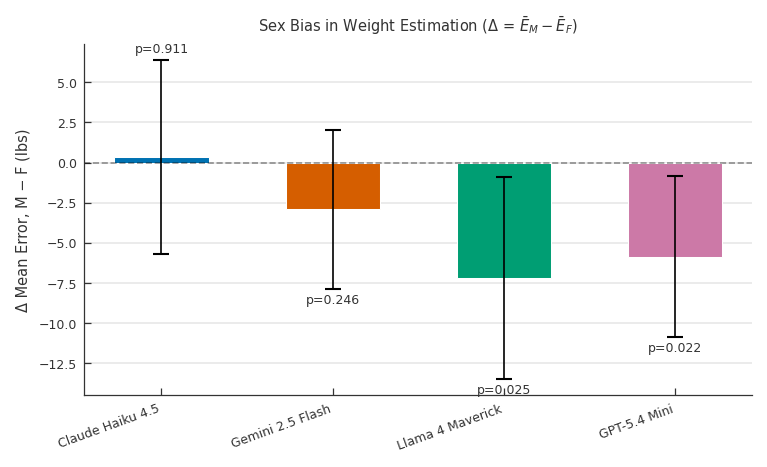

In [27]:
# Bar chart: Δ(M − F) directional error with 95% CI and p-values
fig, ax = plt.subplots(figsize=(5.0, 3.0), layout="constrained")

x = np.arange(len(MODELS))
bar_w = 0.55
colors = [MODEL_COLORS[m] for m in MODELS]

delta_vals = bias_df["Δ (M − F)"].values
ci_vals = bias_df["CI95 (Δ)"].values

ax.bar(x, delta_vals, bar_w, yerr=ci_vals, capsize=4, color=colors,
       edgecolor="white", linewidth=0.5, error_kw={"linewidth": 0.8})
ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)

for i, row in bias_df.iterrows():
    p = row["p-value"]
    label = f"p={p:.3f}" if p >= 0.001 else f"p={p:.1e}"
    y = delta_vals[i] + ci_vals[i] if delta_vals[i] >= 0 else delta_vals[i] - ci_vals[i]
    va = "bottom" if delta_vals[i] >= 0 else "top"
    offset = 0.3 if delta_vals[i] >= 0 else -0.3
    ax.text(i, y + offset, label, ha="center", va=va, fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_LABELS, rotation=20, ha="right")
ax.set_ylabel("Δ Mean Error, M − F (lbs)")
ax.set_title("Sex Bias in Weight Estimation (Δ = $\\bar{E}_M - \\bar{E}_F$)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/posthoc_sex_bias_wgd.png", dpi=300, bbox_inches="tight")
plt.show()